Vorgehensweise: 

1) Daten laden
2) Daten überprüfen und ggf. bereinigen

3) Berechnungen, Datenanalyse und Visualisierungen für das jeweilige Kapitel


1) Daten laden

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Datei aus Unterordner laden
df = pd.read_csv("data/data_in_use/diabetes_binary_health_indicators_BRFSS2015.csv")

# Erste 5 Zeilen anzeigen
df.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


2) Daten überprüfen und ggf. bereinigen

In [604]:
# Anzahl der Datensaätze und Spalten
df.shape

(253680, 24)

In [605]:
# Zeigt Spaltennamen, Anzahl Werte und Datentyp an
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Status          253680 non-null  int8 
 1   Bluthochdruck            253680 non-null  int8 
 2   Cholesterin_hoch         253680 non-null  int8 
 3   Cholesterin_Check        253680 non-null  int8 
 4   BMI                      253680 non-null  int8 
 5   Raucher_Status           253680 non-null  int8 
 6   Schlaganfall             253680 non-null  int8 
 7   Herzerkrankung_Infarkt   253680 non-null  int8 
 8   Sportliche_Aktivitaet    253680 non-null  int8 
 9   Obst_Konsum              253680 non-null  int8 
 10  Gemuese_Konsum           253680 non-null  int8 
 11  Hoher_Alkoholkonsum      253680 non-null  int8 
 12  Krankenversicherung      253680 non-null  int8 
 13  Kein_Arzt_wegen_Kosten   253680 non-null  int8 
 14  Allgemeine_Gesundheit    253680 non-null  int8 

In [606]:
# Spaltennamen auf deutsch übersetzen
# Dictionary für die Übersetzung
uebersetzung = {
    "Diabetes_binary": "Diabetes_Status",
    "HighBP": "Bluthochdruck",
    "HighChol": "Cholesterin_hoch",
    "CholCheck": "Cholesterin_Check",
    "BMI": "BMI",
    "Smoker": "Raucher_Status",
    "Stroke": "Schlaganfall",
    "HeartDiseaseorAttack": "Herzerkrankung_Infarkt",
    "PhysActivity": "Sportliche_Aktivitaet",
    "Fruits": "Obst_Konsum",
    "Veggies": "Gemuese_Konsum",
    "HvyAlcoholConsump": "Hoher_Alkoholkonsum",
    "AnyHealthcare": "Krankenversicherung",
    "NoDocbcCost": "Kein_Arzt_wegen_Kosten",
    "GenHlth": "Allgemeine_Gesundheit",
    "MentHlth": "Psychische_Gesundheit",
    "PhysHlth": "Koerperliche_Gesundheit",
    "DiffWalk": "Einschränkung_Gehen",
    "Sex": "Geschlecht",
    "Age": "Altersgruppe",
    "Education": "Bildungsstand",
    "Income": "Einkommensstufe",
    "BMI_Kategorie_Text": "BMI_Kategorie_Text", 
}

# Spalten im Dataframe umbenennen
df = df.rename(columns=uebersetzung)

#Check
print("Die übersetzten Spaltennamen im Überblick:")
display(pd.DataFrame(df.columns, columns=["Neue_Spaltennamen"]))

Die übersetzten Spaltennamen im Überblick:


,Neue_Spaltennamen
0,Diabetes_Status
1,Bluthochdruck
2,Cholesterin_hoch
3,Cholesterin_Check
4,BMI
5,Raucher_Status
6,Schlaganfall
7,Herzerkrankung_Infarkt
8,Sportliche_Aktivitaet
9,Obst_Konsum


In [607]:
# Liste der float64 Spalten die in int8 umgewandelt werden sollen
int8_spalten = [
    "Diabetes_Status",
    "Bluthochdruck",
    "Cholesterin_hoch",
    "Cholesterin_Check",
    "BMI",  
    "Raucher_Status",
    "Schlaganfall",
    "Herzerkrankung_Infarkt",
    "Sportliche_Aktivitaet",
    "Obst_Konsum",
    "Gemuese_Konsum",
    "Hoher_Alkoholkonsum",
    "Krankenversicherung",
    "Kein_Arzt_wegen_Kosten",
    "Allgemeine_Gesundheit",
    "Psychische_Gesundheit",
    "Koerperliche_Gesundheit",
    "Einschränkung_Gehen",
    "Geschlecht",
    "Altersgruppe",
    "Bildungsstand",
    "Einkommensstufe"
]

# Alle aufgelisteten Spalten in int8 konvertieren
df[int8_spalten] = df[int8_spalten].astype("int8")

In [608]:
df.info()

# 8-Werte-Übersicht pro Spalte
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Status          253680 non-null  int8 
 1   Bluthochdruck            253680 non-null  int8 
 2   Cholesterin_hoch         253680 non-null  int8 
 3   Cholesterin_Check        253680 non-null  int8 
 4   BMI                      253680 non-null  int8 
 5   Raucher_Status           253680 non-null  int8 
 6   Schlaganfall             253680 non-null  int8 
 7   Herzerkrankung_Infarkt   253680 non-null  int8 
 8   Sportliche_Aktivitaet    253680 non-null  int8 
 9   Obst_Konsum              253680 non-null  int8 
 10  Gemuese_Konsum           253680 non-null  int8 
 11  Hoher_Alkoholkonsum      253680 non-null  int8 
 12  Krankenversicherung      253680 non-null  int8 
 13  Kein_Arzt_wegen_Kosten   253680 non-null  int8 
 14  Allgemeine_Gesundheit    253680 non-null  int8 

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Code
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,2.239597
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,1.134719
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,2.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,5.000000


In [609]:
# Check doppelte Werte 
df.duplicated().sum()

np.int64(24206)

In [610]:
 # Zeigt alle Zeilen an, die im Datensatz mehrfach vorkommen
df_duplicates = df[df.duplicated(keep=False)]
df_duplicates

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Text,BMI_Kategorie_Code
5,0,1,1,1,25,1,0,0,1,1,...,2,0,2,0,1,10,6,8,Übergewicht (25.0 - 29.9),2
25,0,0,0,1,32,0,0,0,1,1,...,2,0,0,0,0,5,6,8,Adipositas Grad I (30.0 - 34.9),3
29,0,0,1,1,31,1,0,0,1,1,...,1,0,0,0,1,12,6,8,Adipositas Grad I (30.0 - 34.9),3
44,0,0,1,1,31,1,0,0,0,1,...,2,0,0,0,0,8,5,8,Adipositas Grad I (30.0 - 34.9),3
52,1,1,1,1,27,1,0,0,0,0,...,5,0,30,1,0,10,4,5,Übergewicht (25.0 - 29.9),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1,1,1,1,33,0,0,0,1,1,...,3,0,0,0,1,9,6,6,Adipositas Grad I (30.0 - 34.9),3
253550,0,0,0,1,25,0,0,0,1,1,...,1,0,0,0,0,7,6,8,Übergewicht (25.0 - 29.9),2
253563,0,0,1,1,24,1,0,0,1,1,...,2,0,0,0,1,8,6,8,Normalgewicht (18.5 - 24.9),1
253597,0,0,0,1,24,0,0,0,1,1,...,2,0,0,0,0,5,6,8,Normalgewicht (18.5 - 24.9),1


In [611]:
# Gruppiert alle identischen Zeilen (Profile) und zählt wie oft sie vorkommen
haeufigste_profile = df.value_counts()

# Zeigt die Top 5 der am häufigsten vorkommenden Profile
haeufigste_profile

Diabetes_Status  Bluthochdruck  Cholesterin_hoch  Cholesterin_Check  BMI  Raucher_Status  Schlaganfall  Herzerkrankung_Infarkt  Sportliche_Aktivitaet  Obst_Konsum  Gemuese_Konsum  Hoher_Alkoholkonsum  Krankenversicherung  Kein_Arzt_wegen_Kosten  Allgemeine_Gesundheit  Psychische_Gesundheit  Koerperliche_Gesundheit  Einschränkung_Gehen  Geschlecht  Altersgruppe  Bildungsstand  Einkommensstufe  BMI_Kategorie_Text             BMI_Kategorie_Code
0                0              0                 1                  21   0               0             0                       1                      1            1               0                    1                    0                       1                      0                      0                        0                    0           6             6              8                Normalgewicht (18.5 - 24.9)    1                     59
                                                                     23   0               0           

In [612]:
# Das absolut häufigste Profil ermitteln

# Zählung einmalig durchführen und speichern
profil_counts = df.value_counts()
haeufigstes_profil_anzahl = profil_counts.iloc[0]

# Als Tabelle darstellen und hochkant drehen (.T)
df_top_profil = pd.DataFrame([profil_counts.index[0]], columns=df.columns).T
df_top_profil.columns = ["Häufigstes_Profil"]

#Check
print(f"Dieses Profil kommt genau {haeufigstes_profil_anzahl:,} Mal im Datensatz vor:")
display(df_top_profil)


Dieses Profil kommt genau 59 Mal im Datensatz vor:


,Häufigstes_Profil
Diabetes_Status,0
Bluthochdruck,0
Cholesterin_hoch,0
Cholesterin_Check,1
BMI,21
Raucher_Status,0
Schlaganfall,0
Herzerkrankung_Infarkt,0
Sportliche_Aktivitaet,1
Obst_Konsum,1


Die gleichen Profile resultieren aus der Art der Befragung. Die Antwortmöglichkeiten sind sehr oft Ja/Nein, so dass es bei einer Gesamtdatenmenge von 253.680 Befragten (Profilen) zu Dopplungen kommen kann. Deshalb wurden diese Datensätze nicht gelöscht.

In [613]:
# Check missing values
df_NaN_True = df.isna()   # mit den beiden Zeilen Anzahl der NaN
df_NaN_True.sum()

Diabetes_Status            0
Bluthochdruck              0
Cholesterin_hoch           0
Cholesterin_Check          0
BMI                        0
Raucher_Status             0
Schlaganfall               0
Herzerkrankung_Infarkt     0
Sportliche_Aktivitaet      0
Obst_Konsum                0
Gemuese_Konsum             0
Hoher_Alkoholkonsum        0
Krankenversicherung        0
Kein_Arzt_wegen_Kosten     0
Allgemeine_Gesundheit      0
Psychische_Gesundheit      0
Koerperliche_Gesundheit    0
Einschränkung_Gehen        0
Geschlecht                 0
Altersgruppe               0
Bildungsstand              0
Einkommensstufe            0
BMI_Kategorie_Text         0
BMI_Kategorie_Code         0
dtype: int64

In [614]:
# Einteilung für BMI-Werte vornehmen
# neue Spalte erstellen und BMI in aktuelle WHO-Klassifikation einordnenzurdnen

def bmi_kategorie_who(bmi):
    if bmi < 18.5:
        return "Untergewicht (< 18.5)"
    elif bmi < 25.0:
        return "Normalgewicht (18.5 - 24.9)"
    elif bmi < 30.0:
        return "Übergewicht (25.0 - 29.9)"
    elif bmi < 35.0:
        return "Adipositas Grad I (30.0 - 34.9)"
    elif bmi < 40.0:
        return "Adipositas Grad II (35.0 - 39.9)"
    else:
        return "Adipositas Grad III (>= 40.0)"

# Spalte anlegen
df["BMI_Kategorie_Text"] = df["BMI"].apply(bmi_kategorie_who)

# Feste Reihenfolge für die Achsensortierung in Grafiken
reihenfolge_who = [
    "Untergewicht (< 18.5)",
    "Normalgewicht (18.5 - 24.9)",
    "Übergewicht (25.0 - 29.9)",
    "Adipositas Grad I (30.0 - 34.9)",
    "Adipositas Grad II (35.0 - 39.9)",
    "Adipositas Grad III (>= 40.0)"
]


In [615]:
# BMI numerische Spalte für die Heatmap
def bmi_kategorie_code(bmi):
    if bmi < 18.5:
        return 0  # Untergewicht
    elif bmi < 25.0:
        return 1  # Normalgewicht
    elif bmi < 30.0:
        return 2  # Übergewicht
    elif bmi < 35.0:
        return 3  # Adipositas Grad I
    elif bmi < 40.0:
        return 4  # Adipositas Grad II
    else:
        return 5  # Adipositas Grad III

# Neue numerische Spalte 
df["BMI_Kategorie_Code"] = df["BMI"].apply(bmi_kategorie_code)

#Check
print("Überprüfung der generierten BMI-Kodes (Auszug):")
display(df[["BMI", "BMI_Kategorie_Text", "BMI_Kategorie_Code"]].head())


Überprüfung der generierten BMI-Kodes (Auszug):


,BMI,BMI_Kategorie_Text,BMI_Kategorie_Code
0,40,Adipositas Grad III (>= 40.0),5
1,25,Übergewicht (25.0 - 29.9),2
2,28,Übergewicht (25.0 - 29.9),2
3,27,Übergewicht (25.0 - 29.9),2
4,24,Normalgewicht (18.5 - 24.9),1


Heatmap: Mit allen numerischen Variablen. Daraus soll sich der Fokus für die Datananylyse ergeben

In [580]:
# Berechnungen: Korrelations-Heatmap

# Korrelationsmatrix für alle numerischen Spalten berechnen
df_numerisch = df.select_dtypes(include=["number"])
corr_matrix = df_numerisch.corr()

#Check
print("Berechnete Korrelationsmatrix (Auszug):")
display(corr_matrix.round(2))


Berechnete Korrelationsmatrix (Auszug):


,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Code
Diabetes_Status,1.00,0.26,0.20,0.06,0.22,0.06,0.11,0.18,-0.12,-0.04,...,0.03,0.29,0.07,0.17,0.22,0.03,0.18,-0.12,-0.16,0.23
Bluthochdruck,0.26,1.00,0.30,0.10,0.21,0.10,0.13,0.21,-0.13,-0.04,...,0.02,0.30,0.06,0.16,0.22,0.05,0.34,-0.14,-0.17,0.23
Cholesterin_hoch,0.20,0.30,1.00,0.09,0.11,0.09,0.09,0.18,-0.08,-0.04,...,0.01,0.21,0.06,0.12,0.14,0.03,0.27,-0.07,-0.09,0.12
Cholesterin_Check,0.06,0.10,0.09,1.00,0.03,-0.01,0.02,0.04,0.00,0.02,...,-0.06,0.05,-0.01,0.03,0.04,-0.02,0.09,0.00,0.01,0.04
BMI,0.22,0.21,0.11,0.03,1.00,0.01,0.02,0.05,-0.15,-0.09,...,0.06,0.24,0.09,0.12,0.20,0.04,-0.04,-0.10,-0.10,0.92
Raucher_Status,0.06,0.10,0.09,-0.01,0.01,1.00,0.06,0.11,-0.09,-0.08,...,0.05,0.16,0.09,0.12,0.12,0.09,0.12,-0.16,-0.12,0.02
Schlaganfall,0.11,0.13,0.09,0.02,0.02,0.06,1.00,0.20,-0.07,-0.01,...,0.03,0.18,0.07,0.15,0.18,0.00,0.13,-0.08,-0.13,0.02
Herzerkrankung_Infarkt,0.18,0.21,0.18,0.04,0.05,0.11,0.20,1.00,-0.09,-0.02,...,0.03,0.26,0.06,0.18,0.21,0.09,0.22,-0.10,-0.14,0.06
Sportliche_Aktivitaet,-0.12,-0.13,-0.08,0.00,-0.15,-0.09,-0.07,-0.09,1.00,0.14,...,-0.06,-0.27,-0.13,-0.22,-0.25,0.03,-0.09,0.20,0.20,-0.15
Obst_Konsum,-0.04,-0.04,-0.04,0.02,-0.09,-0.08,-0.01,-0.02,0.14,1.00,...,-0.04,-0.10,-0.07,-0.04,-0.05,-0.09,0.06,0.11,0.08,-0.09


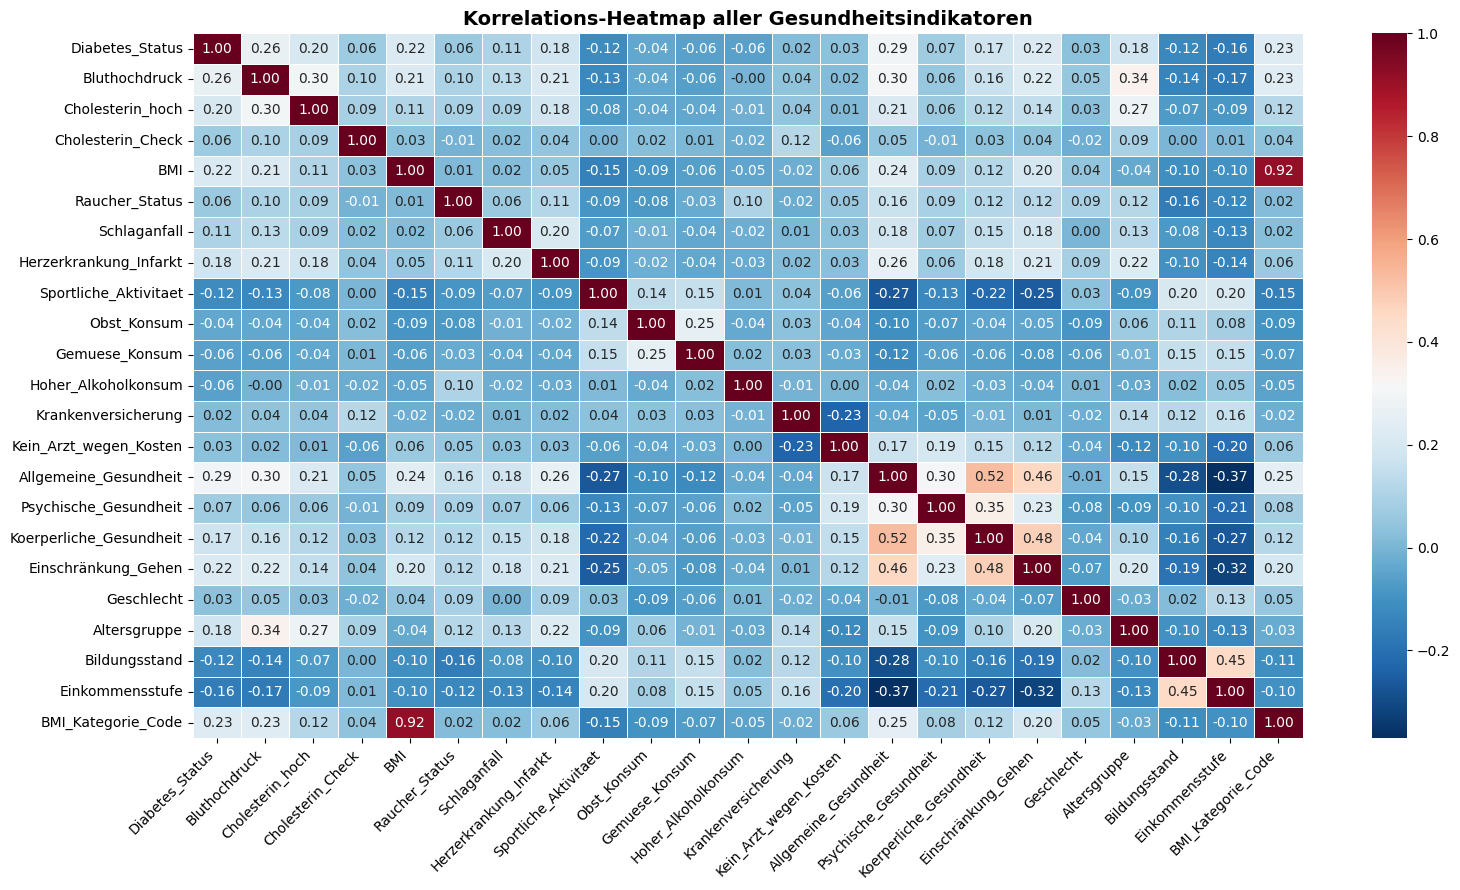

In [581]:
# Grafik: Korrelations-Heatmap aller Gesundheitsindikatoren

# Korrelationsmatrix berechnen
df_numerisch = df.select_dtypes(include=["number"])
corr_matrix = df_numerisch.corr()

plt.figure(figsize=(16, 9))

# Heatmap plotten
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5
)

# Titel & Achsen
plt.title("Korrelations-Heatmap aller Gesundheitsindikatoren", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


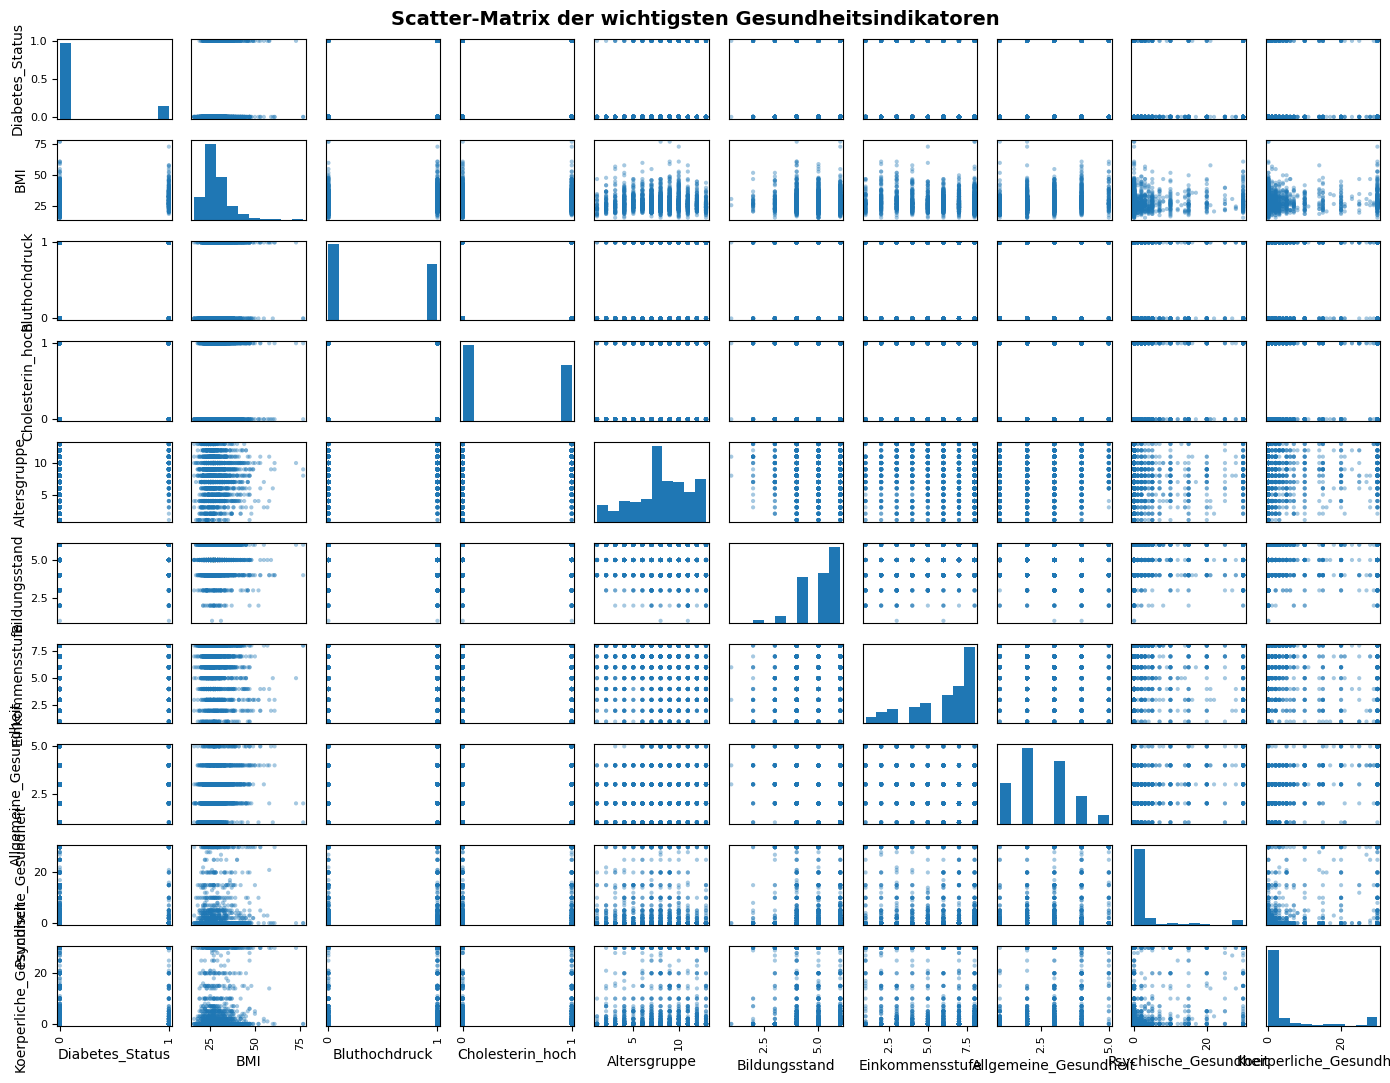

In [582]:
# Grafik: Scatter-Matrix der wichtigsten Gesundheitsindikatoren

kern_merkmale = [
    "Diabetes_Status", "BMI", "Bluthochdruck", "Cholesterin_hoch", 
    "Altersgruppe", "Bildungsstand", "Einkommensstufe", 
    "Allgemeine_Gesundheit", "Psychische_Gesundheit", "Koerperliche_Gesundheit"
]

# Stichprobe ziehen
df_auswahl = df[kern_merkmale].sample(n=2000, random_state=42)

# Scatter-Matrix plotten
axes = pd.plotting.scatter_matrix(
    df_auswahl,
    figsize=(14, 11),
    alpha=0.4,
    diagonal="hist",
    grid=False
)

# Titel hinzufügen
plt.suptitle("Scatter-Matrix der wichtigsten Gesundheitsindikatoren", fontsize=14, fontweight="bold", y=0.98)

plt.tight_layout()
plt.show()


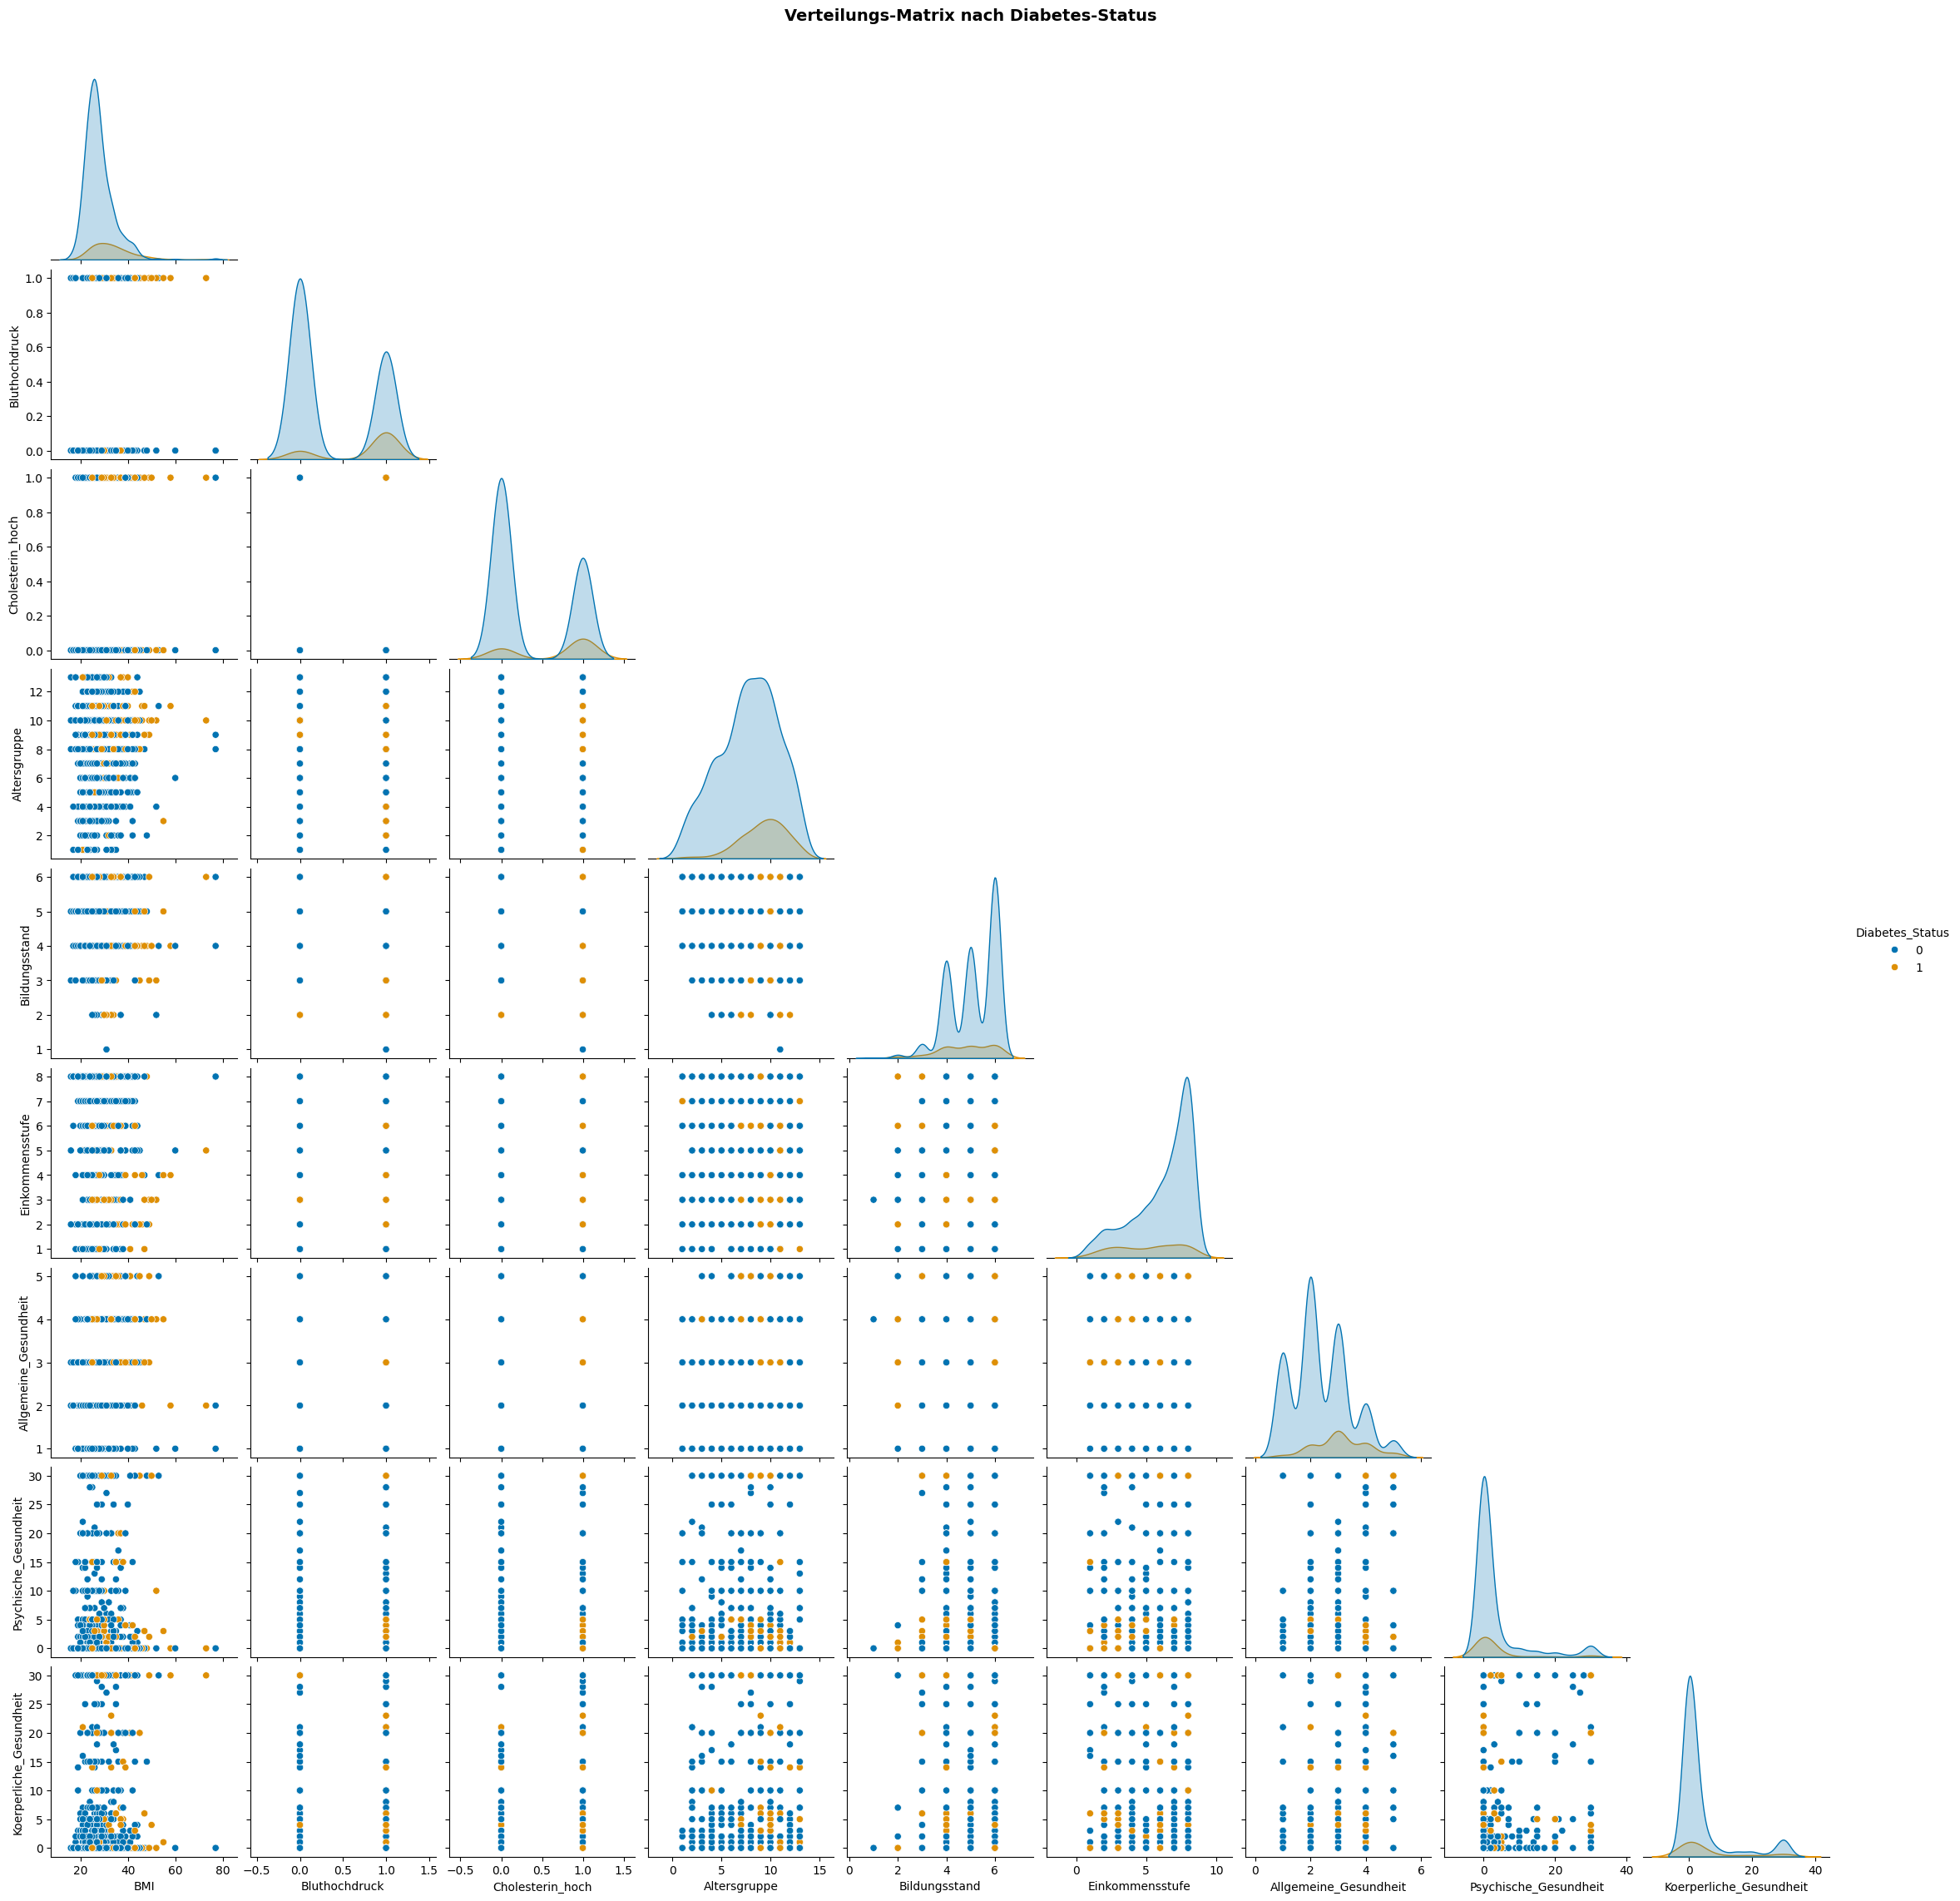

In [583]:
# Grafik: Verteilungs-Matrix nach Diabetes-Status

# Stichprobe für besseres Rendering ziehen
df_sample = df.sample(n=1000, random_state=42)

uebersicht_spalten = [
    "BMI", "Bluthochdruck", "Cholesterin_hoch", "Altersgruppe",
    "Bildungsstand", "Einkommensstufe", "Allgemeine_Gesundheit",
    "Psychische_Gesundheit", "Koerperliche_Gesundheit"
]

# Pairplot erstellen
g = sns.pairplot(
    data=df_sample[uebersicht_spalten + ["Diabetes_Status"]],
    hue="Diabetes_Status",
    palette="colorblind",
    vars=uebersicht_spalten,
    corner=True,
    diag_kind="kde"
)

# Titel hinzufügen
g.figure.suptitle("Verteilungs-Matrix nach Diabetes-Status", fontsize=14, fontweight="bold", y=1.02)

plt.show()


3) Datenanalyse und Visualsierungen

Daten sind strukturell in (X) und (y) aufgeteilt, wie man es für eine logistische Regression vorbereiten würde. 
Der Datensatz bleibt so organisiert, daß im Folgenden statistischen Häufigkeiten zwischen den Gruppen analysiert werden können.

Aus der Heatmap ergeben sich folgende Möglichkeiten zur Untersuchung: Wobei ich sehen möchte ob es einen Unterschied für Geschlechter gibt (den Aspekt werde ich evtl. wieder herausnehmen, wenn es zu aufwändig wird ---- Visualisierungen etc.)

1) wie erwartet der BMI
2) Bluthochdruck und Cholesterin 

3) Alter und Demografie
   Bildungsstand / Einkommenstufe

4) Lebensqualität und Folgeerscheinungen
   Frage könnte sein : Wie beeinflusst Diabetes die subjektive Lebensqualität und die mentale Gesundheit?
   Untersuchung der Variablen Allgemeine Gesundheit,  
                              Mentale Gesundheit und 
                              Körperliche Gesundheit. 
    Wieviel schlechter (viele Tage im Monat) fühlen sich Diabetiker im Vergleich zu Gesunden?





Datenanalyse und Visualisierung 

3.1 nach Geschlecht

3.2 nach BMI

3.1 nach Geschlecht

In [584]:
#Check
print(f"Gesamtanzahl der Datensätze: {len(df['Geschlecht']):,}")
print("\nVerteilung nach Geschlecht:")
display(df['Geschlecht'].map({0.0: 'Frauen (0.0)', 1.0: 'Männer (1.0)'}).value_counts().to_frame(name="Anzahl"))


Gesamtanzahl der Datensätze: 253,680

Verteilung nach Geschlecht:


,Anzahl
Geschlecht,
Frauen (0.0),141974
Männer (1.0),111706


In [585]:
# Berechnungen: Zusammensetzung gesamt und nach Geschlecht

# Prozentualen Anteil berechnen (Total = 100%)
gesamt_aufteilung = pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100

#Check
print("Zusammensetzung der Gesamtbevölkerung in % (0=Frauen/Gesund, 1=Männer/Diabetes):")
display(gesamt_aufteilung)


Zusammensetzung der Gesamtbevölkerung in % (0=Frauen/Gesund, 1=Männer/Diabetes):


Diabetes_Status,0,1
Geschlecht,,
0,48.708215,7.257569
1,37.358483,6.675733


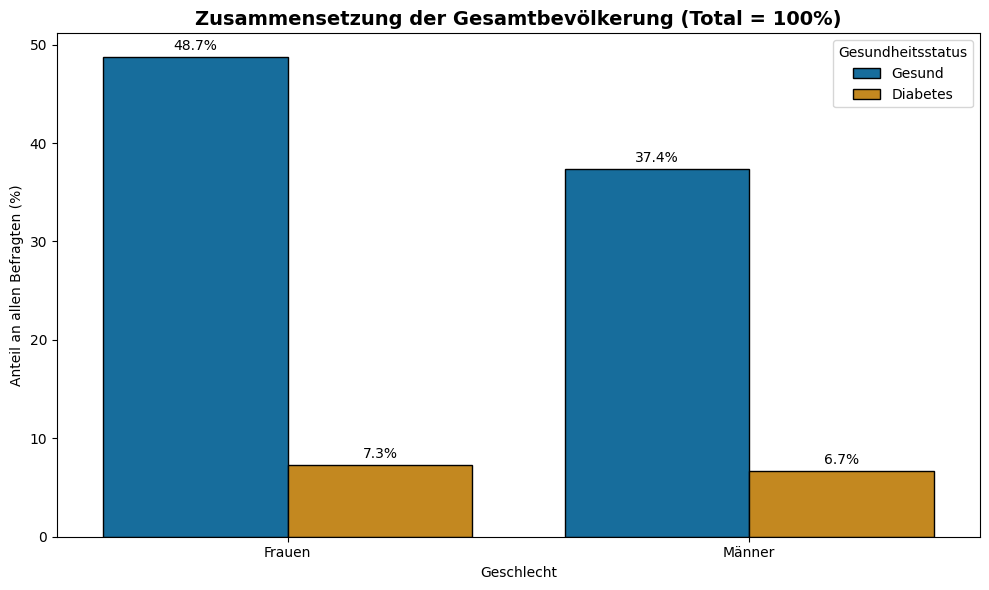

In [586]:
# Grafik: Zusammensetzung der Gesamtbevölkerung

# Anteile berechnen
gesamt_aufteilung = pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100
gesamt_df = gesamt_aufteilung.stack().reset_index()
gesamt_df.columns = ["Geschlecht", "Diabetes_Status", "Prozent_an_Gesamtpopulation"]

# Text-Mapping
gesamt_df["Geschlecht"] = gesamt_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})
gesamt_df["Diabetes_Status"] = gesamt_df["Diabetes_Status"].map({0: "Gesund", 1: "Diabetes"})

plt.figure(figsize=(10, 6))

# Balkendiagramm
ax = sns.barplot(
    data=gesamt_df,
    x="Geschlecht",
    y="Prozent_an_Gesamtpopulation",
    hue="Diabetes_Status",
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Zusammensetzung der Gesamtbevölkerung (Total = 100%)", fontsize=14, fontweight="bold")
plt.xlabel("Geschlecht")
plt.ylabel("Anteil an allen Befragten (%)")

plt.legend(title="Gesundheitsstatus", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()



3.2 nach BMI

In [587]:
#Checks
print(df[["BMI", "BMI_Kategorie_Text"]].value_counts().sort_index())

df[df["BMI"] >= 40]["BMI"].value_counts()

BMI  BMI_Kategorie_Text           
12   Untergewicht (< 18.5)              6
13   Untergewicht (< 18.5)             21
14   Untergewicht (< 18.5)             41
15   Untergewicht (< 18.5)            132
16   Untergewicht (< 18.5)            348
                                     ... 
91   Adipositas Grad III (>= 40.0)      1
92   Adipositas Grad III (>= 40.0)     32
95   Adipositas Grad III (>= 40.0)     12
96   Adipositas Grad III (>= 40.0)      1
98   Adipositas Grad III (>= 40.0)      7
Name: count, Length: 84, dtype: int64


BMI
40    2258
41    1659
42    1639
43    1500
44    1043
45     819
46     750
47     622
48     484
49     416
50     372
51     253
53     237
52     215
55     169
54     113
56     109
57      86
58      71
79      66
60      63
87      61
77      55
59      54
75      52
81      49
71      49
73      47
84      44
62      43
82      37
61      35
63      34
92      32
89      28
64      24
65      19
74      16
67      15
70      15
68      14
72      14
66      13
95      12
69       9
98       7
76       3
88       2
83       2
80       2
85       1
96       1
91       1
86       1
90       1
78       1
Name: count, dtype: int64

In [588]:
# Berechnung: Absolute Häufigkeiten und Raten nach WHO-BMI-Klassen

# Absolute Anzahl und Raten berechnen
bmi_counts = df["BMI_Kategorie_Text"].value_counts()
bmi_rates_who = df.groupby("BMI_Kategorie_Text")["Diabetes_Status"].mean() * 100

# In einer Tabelle zusammenführen und nach WHO sortieren
bmi_zusammenfassung = pd.DataFrame({
    "Anzahl_Personen": bmi_counts,
    "Diabetes_Rate_%": bmi_rates_who
}).reindex(reihenfolge_who)

#Check
print("Übersicht der WHO-BMI-Kategorien im Datensatz:")
display(bmi_zusammenfassung)


Übersicht der WHO-BMI-Kategorien im Datensatz:


,Anzahl_Personen,Diabetes_Rate_%
BMI_Kategorie_Text,,
Untergewicht (< 18.5),3127,5.404541
Normalgewicht (18.5 - 24.9),68953,5.696634
Übergewicht (25.0 - 29.9),93749,11.404922
Adipositas Grad I (30.0 - 34.9),53451,19.234439
Adipositas Grad II (35.0 - 39.9),20663,27.435513
Adipositas Grad III (>= 40.0),13737,33.537162


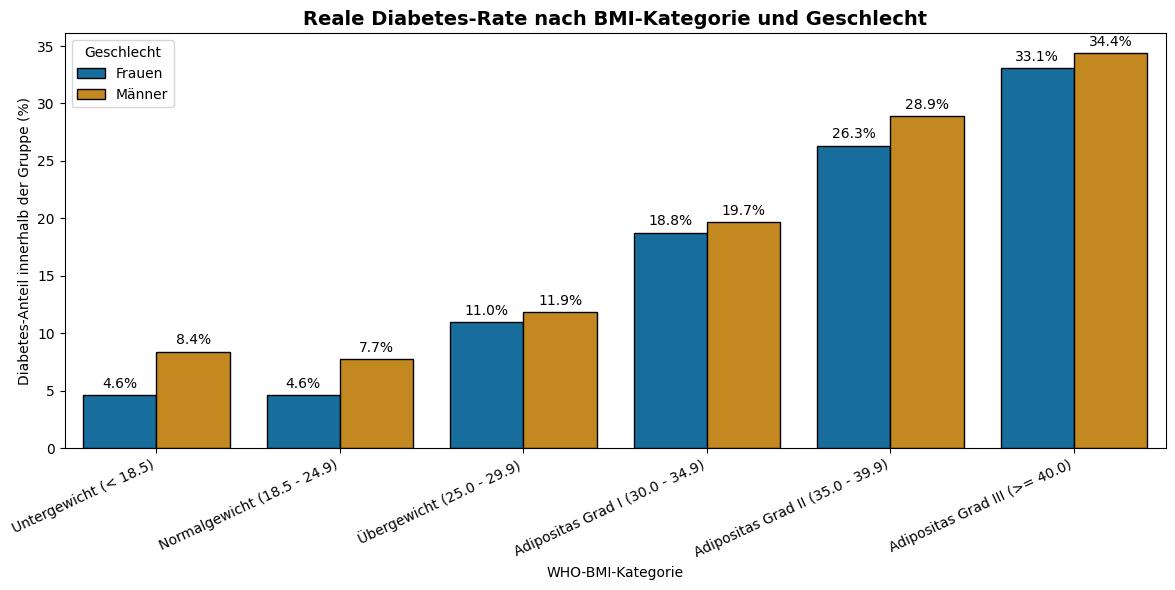

In [589]:
# Berechnung und Grafik: Diabetes-Rate nach BMI-Kategorie und Geschlecht

# Raten berechnen
bmi_geschlecht_rates = (df.groupby(["BMI_Kategorie_Text", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()       
bmi_geschlecht_rates["Geschlecht"] = bmi_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

plt.figure(figsize=(12, 6))

# Gruppiertes Balkendiagramm
ax = sns.barplot(
    data=bmi_geschlecht_rates,
    x="BMI_Kategorie_Text",
    y="Diabetes_Status",
    hue="Geschlecht",
    order=reihenfolge_who,
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Reale Diabetes-Rate nach BMI-Kategorie und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("WHO-BMI-Kategorie")
plt.ylabel("Diabetes-Anteil innerhalb der Gruppe (%)")

plt.xticks(rotation=25, ha="right")
plt.legend(title="Geschlecht", loc="upper left")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


Achtung ab hier weiter arbeiten und überprüfen....

In [590]:
# Berechnungen: Risikopunkt nach BMI

# Relevanten BMI-Bereich filtern
df_kurve_gefiltert = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]

# Die reale Diabetes-Rate pro exaktem BMI-Wert berechnen (in %)
bmi_trend_gefiltert = df_kurve_gefiltert.groupby("BMI")["Diabetes_Status"].mean() * 100

#Check
print("Berechnete Diabetes-Rate pro BMI-Wert:")
display(bmi_trend_gefiltert.to_frame(name="Diabetes_Rate_%"))


Berechnete Diabetes-Rate pro BMI-Wert:


,Diabetes_Rate_%
BMI,
18,4.603439
19,3.402218
20,3.809072
21,4.860477
22,5.064868
23,5.848815
24,7.514066
25,8.462615
26,9.736407


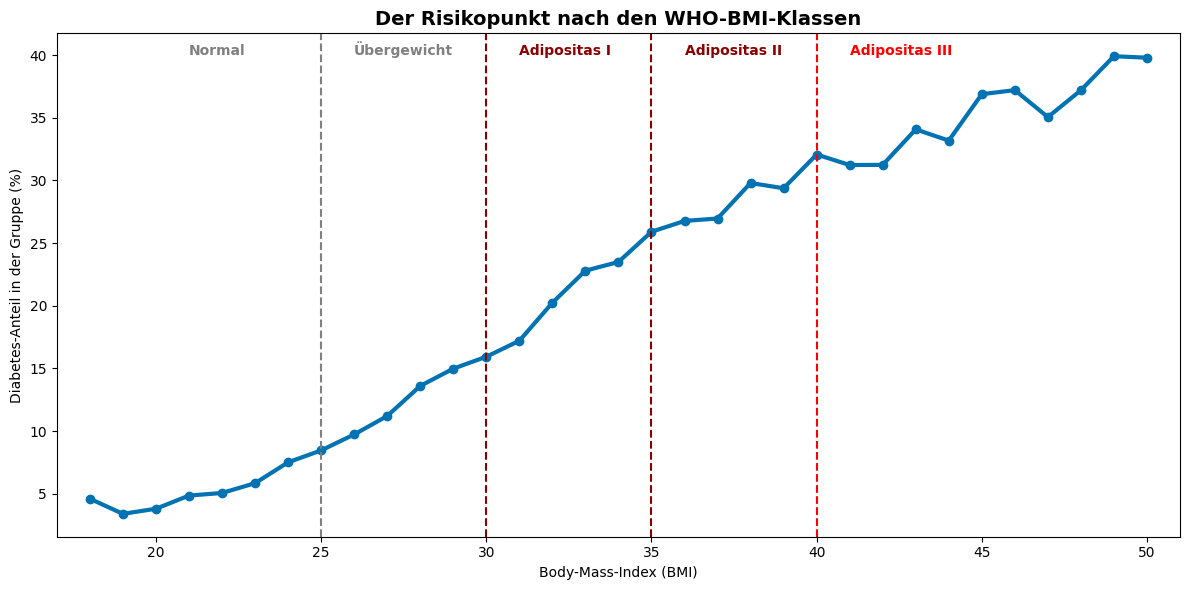

In [591]:

# Grafik: Der Risikopunkt nach den WHO-BMI-Klassen

# Filter und Berechnung
df_kurve = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]
bmi_trend = df_kurve.groupby("BMI")["Diabetes_Status"].mean() * 100

plt.figure(figsize=(12, 6))

# Kurve mit der Standardfarbe aus der Palette plotten
blue_color = sns.color_palette("colorblind")[0]
plt.plot(
    bmi_trend.index,
    bmi_trend.values,
    color=blue_color,
    linewidth=3,
    marker="o"
)

# WHO-Klassen Grenzlinien
plt.axvline(x=25, color="gray", linestyle="--")
plt.axvline(x=30, color="darkred", linestyle="--")
plt.axvline(x=35, color="darkred", linestyle="--")
plt.axvline(x=40, color="red", linestyle="--")

# Textmarkierungen einheitlich auf Höhe 40% gesetzt
plt.text(21, 40, "Normal", color="gray", fontweight="bold")
plt.text(26, 40, "Übergewicht", color="gray", fontweight="bold")
plt.text(31, 40, "Adipositas I", color="darkred", fontweight="bold")
plt.text(36, 40, "Adipositas II", color="darkred", fontweight="bold")
plt.text(41, 40, "Adipositas III", color="red", fontweight="bold")

# Titel & Achsen
plt.title("Der Risikopunkt nach den WHO-BMI-Klassen", fontsize=14, fontweight="bold")
plt.xlabel("Body-Mass-Index (BMI)")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xlim(17, 51)

plt.tight_layout()
plt.show()


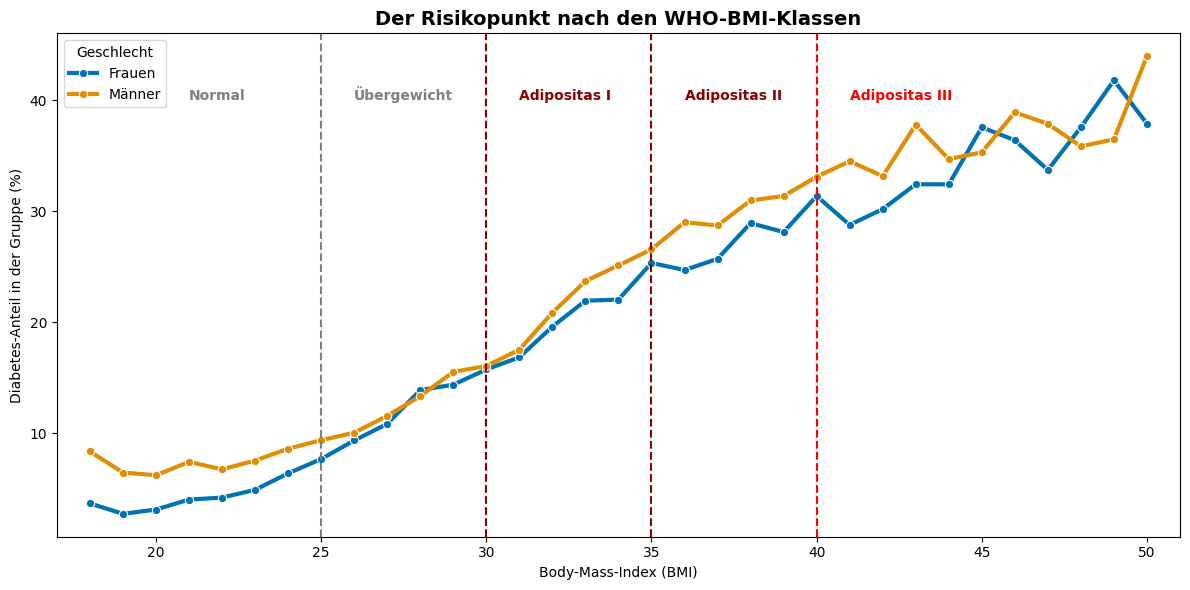

In [592]:
# Grafik: Der Risikopunkt nach den WHO-BMI-Klassen (Männer und Frauen)

# Filter und Berechnung
df_kurve = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]
trend_geschlecht = df_kurve.groupby(["BMI", "Geschlecht"])["Diabetes_Status"].mean().reset_index()
trend_geschlecht["Diabetes_Status"] *= 100
trend_geschlecht["Geschlecht"] = trend_geschlecht["Geschlecht"].map({0: "Frauen", 1: "Männer"})

plt.figure(figsize=(12, 6))

# Liniendiagramm
ax = sns.lineplot(
    data=trend_geschlecht,
    x="BMI",
    y="Diabetes_Status",
    hue="Geschlecht",
    palette="colorblind",
    linewidth=3,
    marker="o"
)

# WHO-Klassen Grenzlinien
plt.axvline(x=25, color="gray", linestyle="--")
plt.axvline(x=30, color="darkred", linestyle="--")
plt.axvline(x=35, color="darkred", linestyle="--")
plt.axvline(x=40, color="red", linestyle="--")

# Textmarkierungen einheitlich auf Höhe 40% 
plt.text(21, 40, "Normal", color="gray", fontweight="bold")
plt.text(26, 40, "Übergewicht", color="gray", fontweight="bold")
plt.text(31, 40, "Adipositas I", color="darkred", fontweight="bold")
plt.text(36, 40, "Adipositas II", color="darkred", fontweight="bold")
plt.text(41, 40, "Adipositas III", color="red", fontweight="bold")

# Titel & Achsen
plt.title("Der Risikopunkt nach den WHO-BMI-Klassen", fontsize=14, fontweight="bold")
plt.xlabel("Body-Mass-Index (BMI)")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xlim(17, 51)
plt.legend(title="Geschlecht", loc="upper left")

plt.tight_layout()
plt.show()





Den Abschnitt bearbeiten

weiter mit Cholesterin udn Bluthochdruck...

danach die anderen Risikofaktoren....
einfacher sie in einem zu berechnen als Überblick
Details dann später

In [593]:
# Berechnungen für alle Faktoren (Übersicht)

# Baseline
baseline_rate = df["Diabetes_Status"].mean() * 100

# Raten für die Risikogruppen berechnen (in %)
rate_bluthochdruck = df[df["Bluthochdruck"] == 1]["Diabetes_Status"].mean() * 100
rate_bmi = df[df["BMI"] >= 30]["Diabetes_Status"].mean() * 100
rate_cholesterin = df[df["Cholesterin_hoch"] == 1]["Diabetes_Status"].mean() * 100
rate_alter = df[df["Altersgruppe"] >= 9]["Diabetes_Status"].mean() * 100
rate_allg_ges = df[df["Allgemeine_Gesundheit"] >= 4]["Diabetes_Status"].mean() * 100
rate_psych_ges = df[df["Psychische_Gesundheit"] > 14]["Diabetes_Status"].mean() * 100
rate_koerp_ges = df[df["Koerperliche_Gesundheit"] > 14]["Diabetes_Status"].mean() * 100
rate_bildung = df[df["Bildungsstand"] == 1]["Diabetes_Status"].mean() * 100
rate_einkommen = df[df["Einkommensstufe"] == 1]["Diabetes_Status"].mean() * 100

# In DataFrame zusammenfassen
faktoren_data_10 = pd.DataFrame({
    "Risikofaktor": [
        "Bluthochdruck", "BMI", "Cholesterin_hoch", "Altersgruppe",
        "Allgemeine_Gesundheit", "Psychische_Gesundheit", 
        "Koerperliche_Gesundheit", "Bildungsstand", "Einkommensstufe"
    ],
    "Diabetes_Rate": [
        rate_bluthochdruck, rate_bmi, rate_cholesterin, rate_alter,
        rate_allg_ges, rate_psych_ges, rate_koerp_ges, rate_bildung, rate_einkommen
    ]
})

# Sortieren
faktoren_data_10 = faktoren_data_10.sort_values(by="Diabetes_Rate", ascending=False)

#Check
print(f"Diabetes-Raten nach den 9 Fokus-Risikofaktoren (Baseline: {baseline_rate:.1f}%):")
display(faktoren_data_10)


Diabetes-Raten nach den 9 Fokus-Risikofaktoren (Baseline: 13.9%):


,Risikofaktor,Diabetes_Rate
4,Allgemeine_Gesundheit,32.915626
6,Koerperliche_Gesundheit,28.590738
7,Bildungsstand,27.011494
0,Bluthochdruck,24.445690
8,Einkommensstufe,24.289063
1,BMI,23.399847
2,Cholesterin_hoch,22.014853
5,Psychische_Gesundheit,21.202396
3,Altersgruppe,19.657603


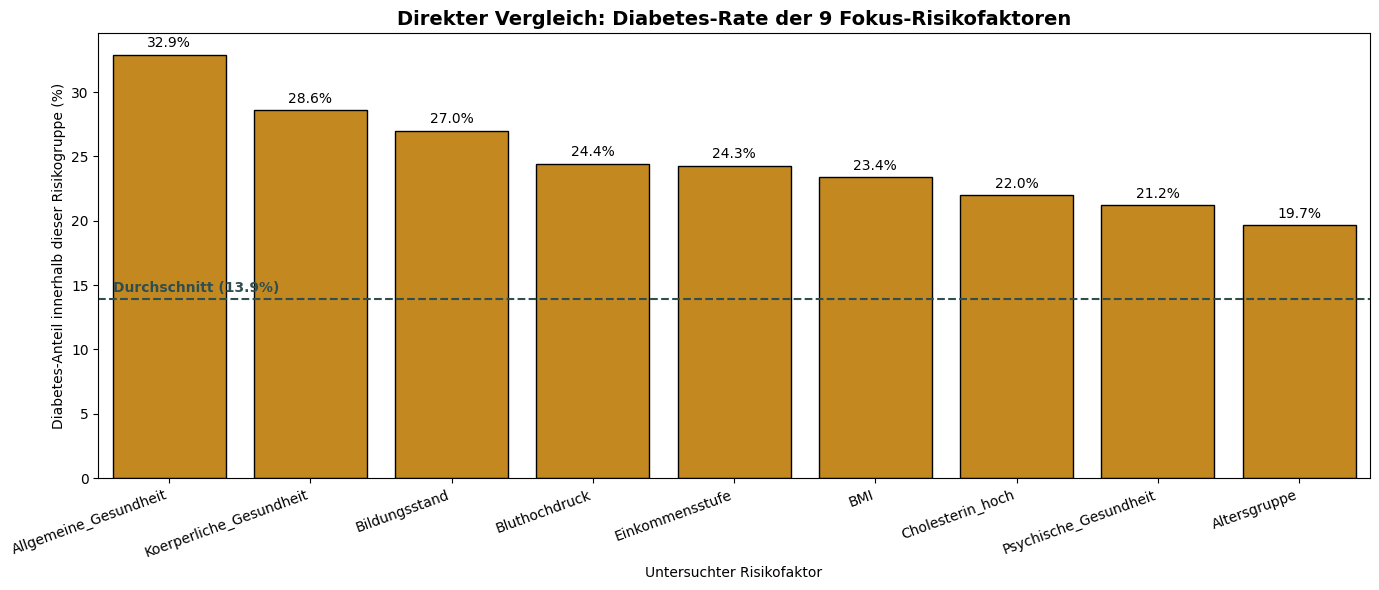

In [594]:
# Grafik: Vergleich der 9 Fokus-Risikofaktoren
plt.figure(figsize=(14, 6))

# Farbe direkt aus der Palette nehmen (Orange ist der 2. Eintrag)
orange_color = sns.color_palette("colorblind")[1]

ax = sns.barplot(
    data=faktoren_data_10,
    x="Risikofaktor",
    y="Diabetes_Rate",
    color=orange_color,  
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Direkter Vergleich: Diabetes-Rate der 9 Fokus-Risikofaktoren", fontsize=14, fontweight="bold")
plt.xlabel("Untersuchter Risikofaktor")
plt.ylabel("Diabetes-Anteil innerhalb dieser Risikogruppe (%)")

plt.xticks(rotation=20, ha="right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


nach Alterstufen und Männer und Frauen unterschieden

In [595]:
# Berechnung Altersgruppe und Geschlecht

# Raten berechnen
alter_geschlecht_rates = (df.groupby(["Altersgruppe", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
alter_geschlecht_rates["Geschlecht_Text"] = alter_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

#Check
print("Diabetes-Raten nach Altersgruppen und Geschlecht:")
display(alter_geschlecht_rates[["Altersgruppe", "Geschlecht_Text", "Diabetes_Status"]])


Diabetes-Raten nach Altersgruppen und Geschlecht:


,Altersgruppe,Geschlecht_Text,Diabetes_Status
0,1,Frauen,1.639344
1,1,Männer,1.116751
2,2,Frauen,2.230018
3,2,Männer,1.413917
4,3,Frauen,3.150775
5,3,Männer,2.430350
6,4,Frauen,4.737864
7,4,Männer,4.263693
8,5,Frauen,6.304729
9,5,Männer,6.765418


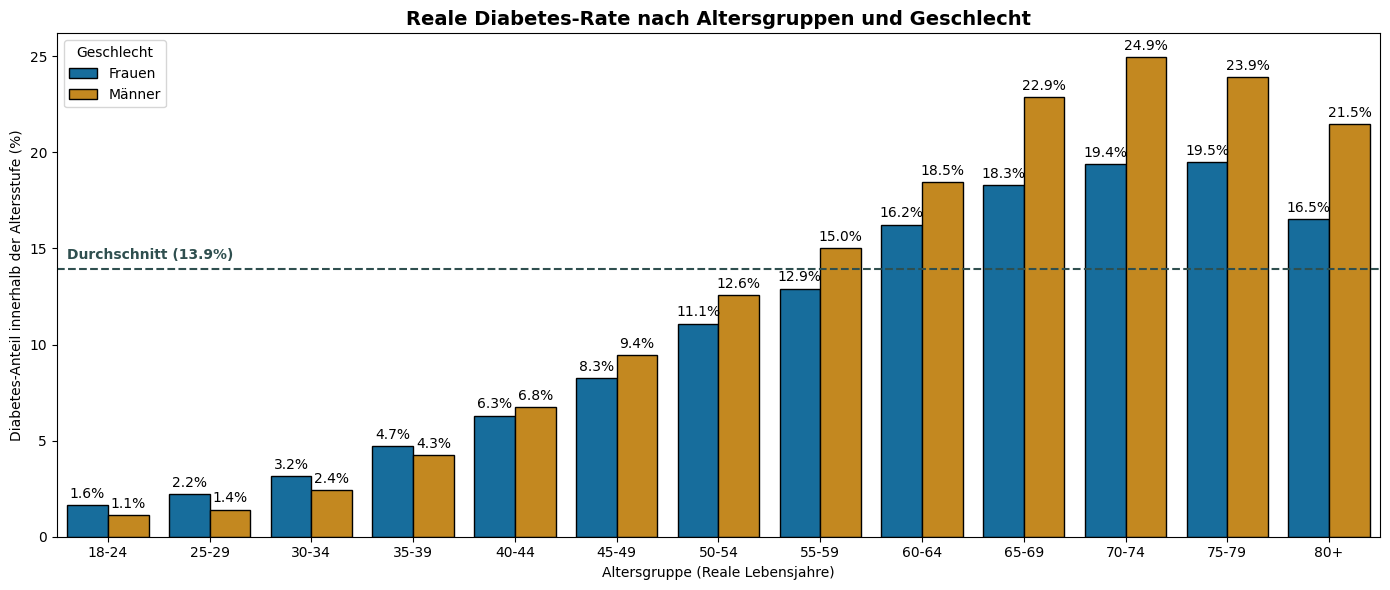

In [596]:
# Grafik: Diabetesrate nach Alter und Geschlecht

echte_jahre_labels = [
    "18-24", "25-29", "30-34", "35-39", "40-44", "45-49",
    "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80+"
]

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=alter_geschlecht_rates,
    x="Altersgruppe",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# Achsenbeschriftung anpassen
plt.xticks(ticks=range(len(echte_jahre_labels)), labels=echte_jahre_labels)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Reale Diabetes-Rate nach Altersgruppen und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Altersgruppe (Reale Lebensjahre)")
plt.ylabel("Diabetes-Anteil innerhalb der Altersstufe (%)")

plt.legend(title="Geschlecht", loc="upper left")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


Cholesterindn und Bluthochdruck nach Geschlechtern


In [597]:
# Berechnung: Bluthochdruck und Cholesterin nach Geschlechtern

# Bluthochdruck
bp_geschlecht = (df.groupby("Geschlecht")["Bluthochdruck"].mean() * 100).reset_index()
bp_geschlecht["Faktor"] = "Bluthochdruck"
bp_geschlecht.rename(columns={"Bluthochdruck": "Anteil"}, inplace=True)

# Cholesterin
chol_geschlecht = (df.groupby("Geschlecht")["Cholesterin_hoch"].mean() * 100).reset_index()
chol_geschlecht["Faktor"] = "Hohes Cholesterin"
chol_geschlecht.rename(columns={"Cholesterin_hoch": "Anteil"}, inplace=True)

# Zusammenführen und Text mappen
herz_risiko_df = pd.concat([bp_geschlecht, chol_geschlecht], axis=0)
herz_risiko_df["Geschlecht_Text"] = herz_risiko_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})

#Check
print("Herz-Kreislauf-Risikofaktoren nach Geschlecht:")
display(herz_risiko_df[["Faktor", "Geschlecht_Text", "Anteil"]])



Herz-Kreislauf-Risikofaktoren nach Geschlecht:


,Faktor,Geschlecht_Text,Anteil
0,Bluthochdruck,Frauen,40.608140
1,Bluthochdruck,Männer,45.813117
0,Hohes Cholesterin,Frauen,41.044135
1,Hohes Cholesterin,Männer,44.150717


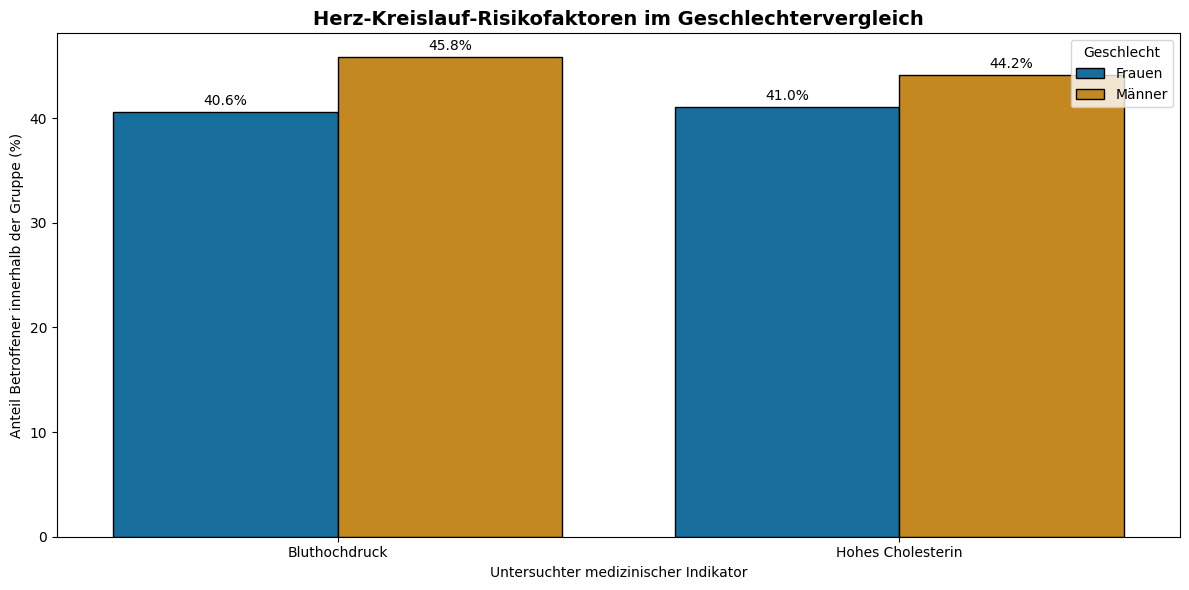

In [598]:
# Grafik: Bluthochdruck und Cholesterin nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=herz_risiko_df,
    x="Faktor",
    y="Anteil",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Herz-Kreislauf-Risikofaktoren im Geschlechtervergleich", fontsize=14, fontweight="bold")
plt.xlabel("Untersuchter medizinischer Indikator")
plt.ylabel("Anteil Betroffener innerhalb der Gruppe (%)")

plt.legend(title="Geschlecht", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()



Bildung und Einkommen nach Geschlechtern 


und  -  nebeneinander 





In [599]:
# Berechnung Bildung nach Geschlecht

# Raten berechnen
bildung_rates = (df.groupby(["Bildungsstand", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
bildung_rates["Geschlecht_Text"] = bildung_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Mapping für X-Achse
bildung_mapping = {
    1: "Keine/Grundschule",
    2: "Elementarstufe",
    3: "High School unvollst.",
    4: "High School Abschl.",
    5: "College unvollst.",
    6: "College Abschl."
}
bildung_rates["Bildungsstufe_Text"] = bildung_rates["Bildungsstand"].map(bildung_mapping)

# Schneller Blick auf die Daten
print("Diabetes-Raten nach Bildungsstand und Geschlecht:")
display(bildung_rates[["Bildungsstufe_Text", "Geschlecht_Text", "Diabetes_Status"]])



Diabetes-Raten nach Bildungsstand und Geschlecht:


,Bildungsstufe_Text,Geschlecht_Text,Diabetes_Status
0,Keine/Grundschule,Frauen,29.411765
1,Keine/Grundschule,Männer,23.611111
2,Elementarstufe,Frauen,31.040807
3,Elementarstufe,Männer,27.175081
4,High School unvollst.,Frauen,24.981858
5,High School unvollst.,Männer,23.171962
6,High School Abschl.,Frauen,17.386105
7,High School Abschl.,Männer,17.951502
8,College unvollst.,Frauen,13.786328
9,College unvollst.,Männer,16.282069


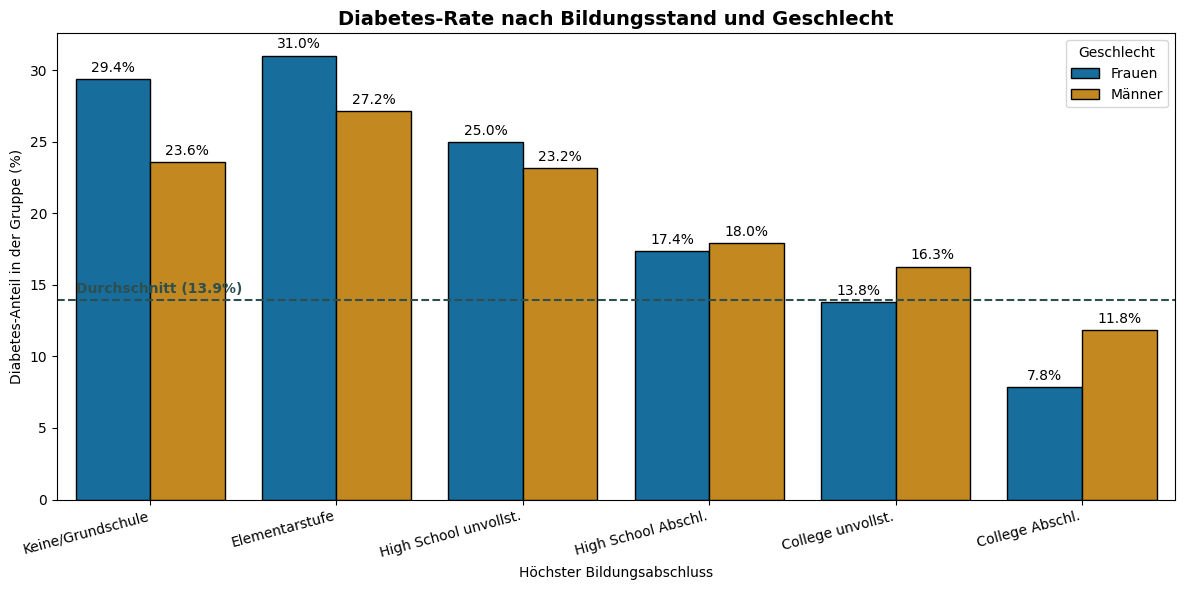

In [600]:
# Grafik: Bildung nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=bildung_rates,
    x="Bildungsstufe_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black"
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach Bildungsstand und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Höchster Bildungsabschluss")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


Einkommen




In [601]:
# Berechnung: Einkommen nach Geschlecht

# Raten berechnen
einkommen_rates = (df.groupby(["Einkommensstufe", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
einkommen_rates["Geschlecht_Text"] = einkommen_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Mapping für X-Achse
einkommen_mapping = {
    1: "<10k $",
    2: "10k-15k $",
    3: "15k-20k $",
    4: "20k-25k $",
    5: "25k-35k $",
    6: "35k-50k $",
    7: "50k-75k $",
    8: ">=75k $",
}
einkommen_rates["Einkommen_Text"] = einkommen_rates["Einkommensstufe"].map(einkommen_mapping)

# Check
print("Diabetes-Raten nach Einkommensstufe und Geschlecht:")
display(einkommen_rates[["Einkommen_Text", "Geschlecht_Text", "Diabetes_Status"]])



Diabetes-Raten nach Einkommensstufe und Geschlecht:


,Einkommen_Text,Geschlecht_Text,Diabetes_Status
0,<10k $,Frauen,25.773971
1,<10k $,Männer,21.159328
2,10k-15k $,Frauen,25.936165
3,10k-15k $,Männer,26.718954
4,15k-20k $,Frauen,21.688238
5,15k-20k $,Männer,23.496172
6,20k-25k $,Frauen,18.764141
7,20k-25k $,Männer,22.533479
8,25k-35k $,Frauen,15.699746
9,25k-35k $,Männer,20.033455


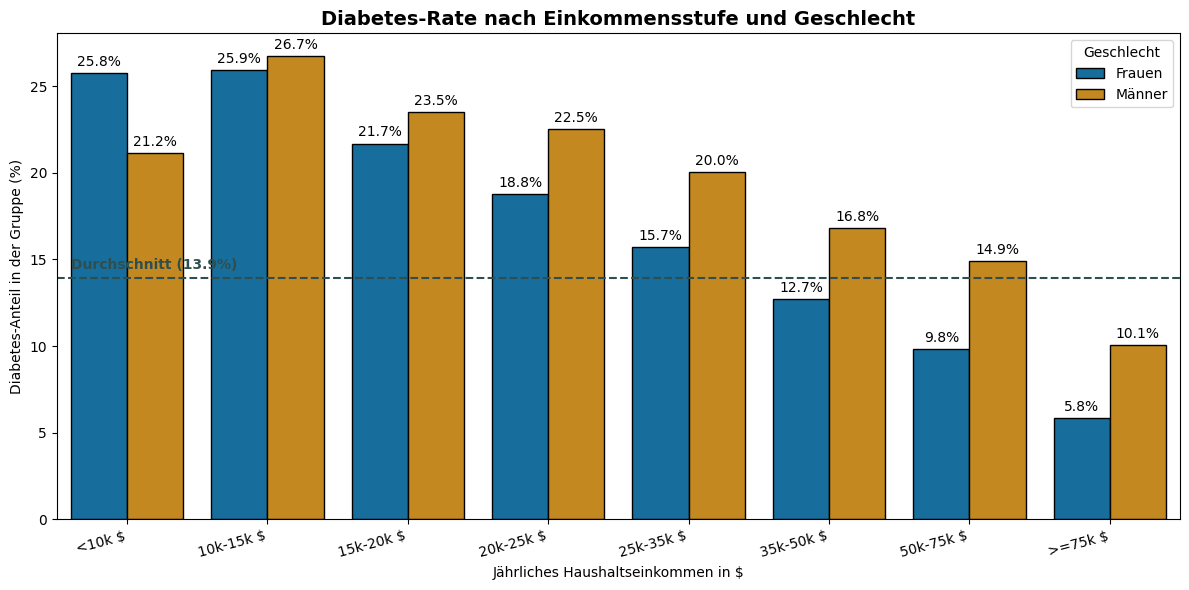

In [602]:
# Grafik: Einkommen nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=einkommen_rates,
    x="Einkommen_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach Einkommensstufe und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Jährliches Haushaltseinkommen in $")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper right")

# Gitter im Hintergrund
#plt.grid(axis="y", linestyle="--")

# Prozentzahlen auf die Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


C:\Users\keron\AppData\Local\Temp\ipykernel_11600\4262602288.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=25, ha="right")
C:\Users\keron\AppData\Local\Temp\ipykernel_11600\4262602288.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha="right")


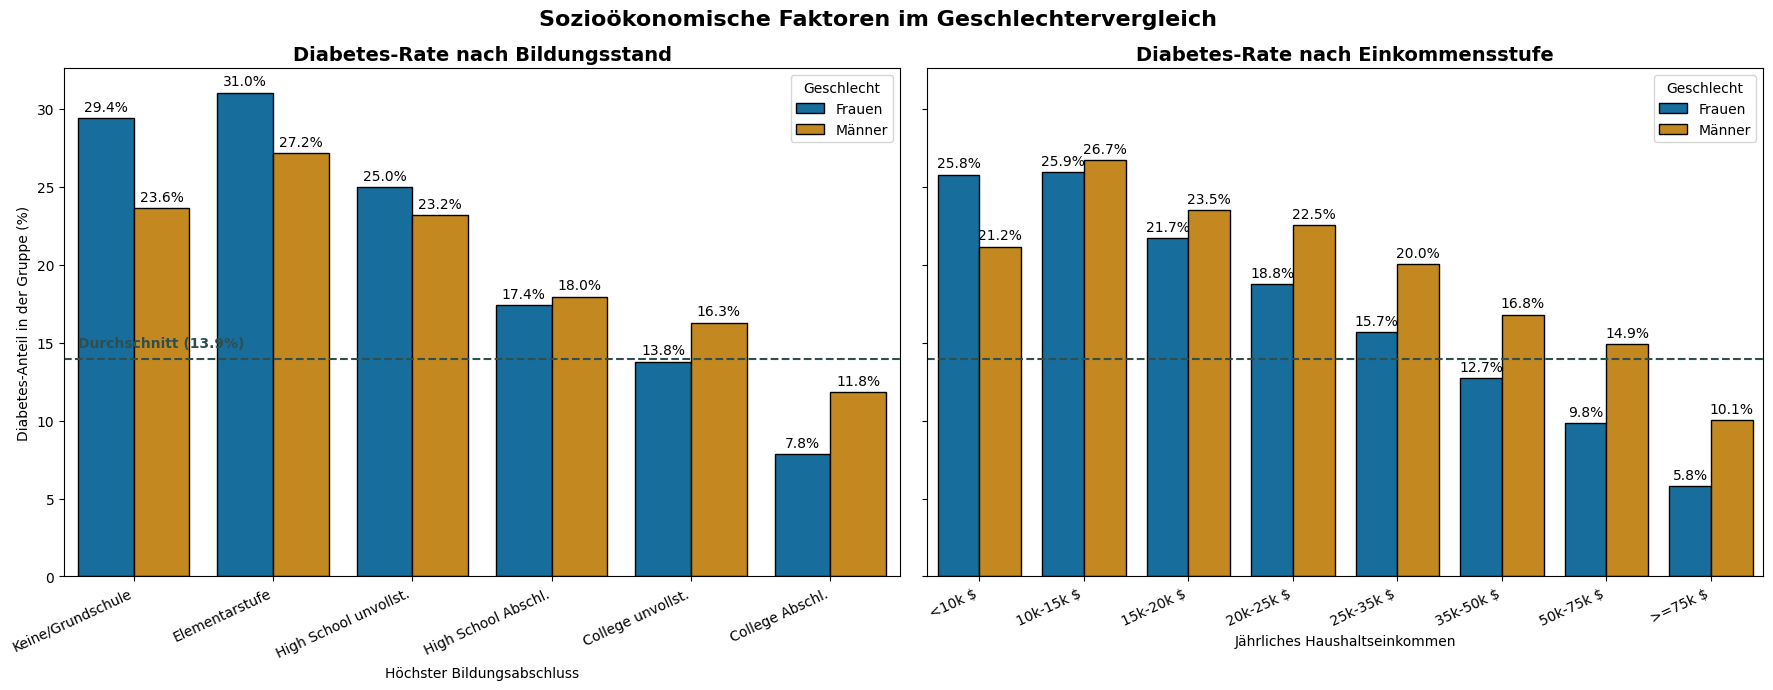

In [603]:
# Grafik: Bildungsstand und Einkommen nebeneinander
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# 1. Plot: Bildung
sns.barplot(
    data=bildung_rates,
    x="Bildungsstufe_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
    ax=ax1,
)
ax1.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
ax1.set_title("Diabetes-Rate nach Bildungsstand", fontsize=14, fontweight="bold")
ax1.set_xlabel("Höchster Bildungsabschluss")
ax1.set_ylabel("Diabetes-Anteil in der Gruppe (%)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=25, ha="right")
ax1.legend(title="Geschlecht", loc="upper right")

# Prozentzahlen an den Balken
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.1f%%", padding=3)

# 2. Plot: Einkommen
sns.barplot(
    data=einkommen_rates,
    x="Einkommen_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
    ax=ax2,
)
ax2.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
ax2.set_title("Diabetes-Rate nach Einkommensstufe", fontsize=14, fontweight="bold")
ax2.set_xlabel("Jährliches Haushaltseinkommen")
ax2.set_ylabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha="right")
ax2.legend(title="Geschlecht", loc="upper right")

for c in ax2.containers:
    ax2.bar_label(c, fmt="%.1f%%", padding=3)

# Baseline Text
ax1.text(
    -0.4,
    baseline_rate + 0.8,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel und Layout
plt.suptitle(
    "Sozioökonomische Faktoren im Geschlechtervergleich",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


Gesundheit:

allgemein
körperlich
psychisch

Problem: 
unterschiedliche Bewertungseinteilungen....  
einzeln als Balken.... NEIN 
oder eine Linie? ja -> einzeln oder nebeneinander 

1) einzeln 
2) nebeneinander

analog zu den restlichen Grafiken...
